In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # Code/
sys.path.append(str(PROJECT_ROOT))

Добавление корневой директории проекта в PYTHONPATH необходимо для корректного импорта модулей src.

# Сравнение процедурных шумов

В данном ноутбуке проводится анализ процедурных шумов:
- Perlin
- Value
- Simplex
- их fBm-модификаций

Анализ проводится для трёх диапазонов частот:
- LOW
- MID
- HIGH

Используемые метрики:
- Энтропия
- Автокорреляция
- Время генерации

In [24]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..")
CSV_PATH = PROJECT_ROOT / "report" / "metrics.csv"

df = pd.read_csv(CSV_PATH)
df


,frequency,method,entropy,autocorr,time_ms
0,low,Perlin,-1385.471101,0.337399,32.249
1,low,Value,-52.980438,0.660547,13.649
2,low,Simplex,-55.480774,0.996874,691.773
3,low,fBm-Perlin,-437.127955,0.425347,68.292
4,low,fBm-Value,-146.782777,0.712434,32.758
5,low,fBm-Simplex,-143.671749,0.995774,1340.519
6,mid,Perlin,-462.936011,0.768674,35.207
7,mid,Value,-43.183084,0.890084,14.905
8,mid,Simplex,-51.983622,0.993581,758.529
9,mid,fBm-Perlin,-363.498434,0.817126,154.560


In [25]:
df.sort_values(["frequency", "method"])

,frequency,method,entropy,autocorr,time_ms
12,high,Perlin,-226.714255,0.935984,38.236
14,high,Simplex,-45.190341,0.986104,657.061
13,high,Value,-36.702532,0.968333,15.541
15,high,fBm-Perlin,-353.905545,0.948967,242.520
17,high,fBm-Simplex,-213.893167,0.960278,3914.262
16,high,fBm-Value,-221.705214,0.972415,104.224
0,low,Perlin,-1385.471101,0.337399,32.249
2,low,Simplex,-55.480774,0.996874,691.773
1,low,Value,-52.980438,0.660547,13.649
3,low,fBm-Perlin,-437.127955,0.425347,68.292


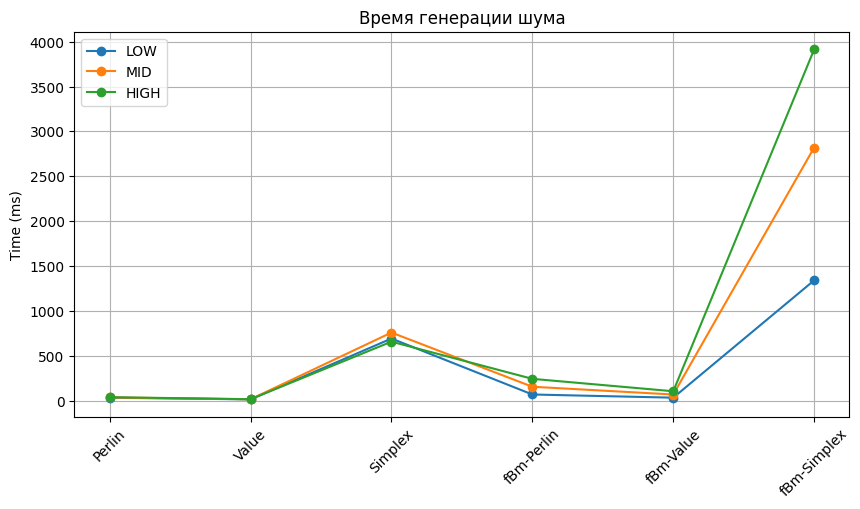

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["time_ms"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Time (ms)")
plt.title("Время генерации шума")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

«Зависимость времени генерации от типа шума»

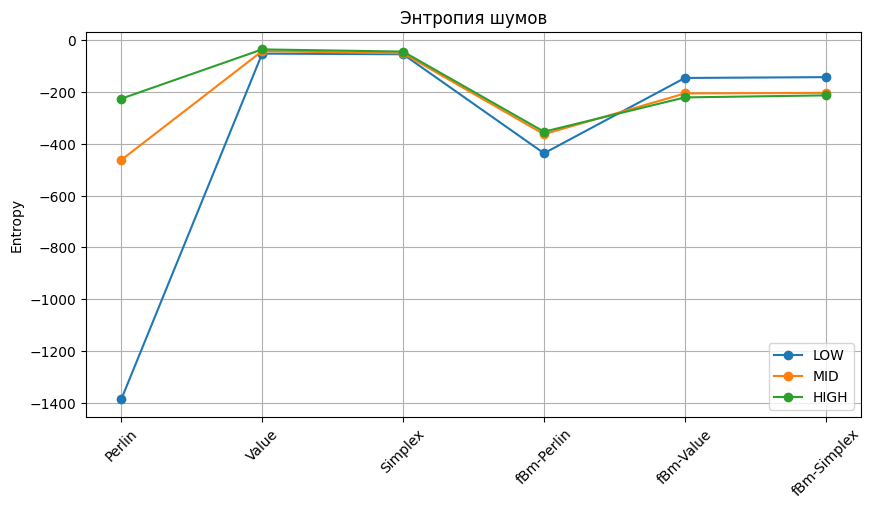

In [27]:
plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["entropy"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Entropy")
plt.title("Энтропия шумов")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

«Сравнение энтропии»

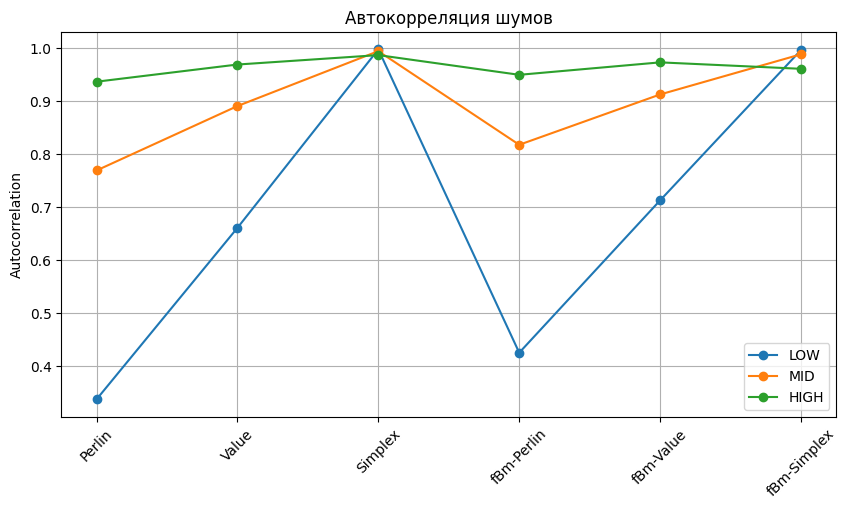

In [28]:
plt.figure(figsize=(10, 5))

for freq in df["frequency"].unique():
    subset = df[df["frequency"] == freq]
    plt.plot(
        subset["method"],
        subset["autocorr"],
        marker="o",
        label=freq.upper()
    )

plt.ylabel("Autocorrelation")
plt.title("Автокорреляция шумов")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

«Сравнение автокорреляции»

Визуальные примеры шумов и их FFT-спектров приведены в приложении (PDF).

## Выводы

1. Value Noise демонстрирует наименьшее время генерации среди рассмотренных методов,
   однако характеризуется меньшей пространственной корреляцией.
2. Simplex Noise обеспечивает высокую гладкость и коррелированность шума,
   но требует значительно больших вычислительных затрат.
3. Применение фрактального броуновского движения (fBm) повышает
   детализированность текстур, при этом существенно увеличивая время генерации,
   особенно при использовании Simplex Noise.
4. Спектральный анализ с использованием FFT подтверждает различие
   частотных характеристик различных типов шума.
5. Выбор метода генерации процедурного шума должен осуществляться
   исходя из требований к визуальному качеству и производительности.

## Примеры процедурных текстур

Ниже приведены примеры процедурных текстур, построенных на основе различных типов шума и их фрактальных модификаций.

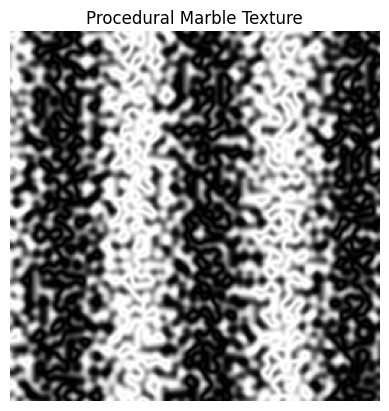

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.noise import perlin_noise

SIZE = 256

noise = perlin_noise(SIZE, SIZE, scale=32, seed=42)

x = np.linspace(0, 5 * np.pi, SIZE)
x, y = np.meshgrid(x, x)

marble = np.sin(x + noise * 5)

marble = (marble - marble.min()) / (marble.max() - marble.min())

plt.imshow(marble, cmap="gray")
plt.title("Procedural Marble Texture")
plt.axis("off")
plt.savefig(
    PROJECT_ROOT / "report" / "texture" / "marble.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

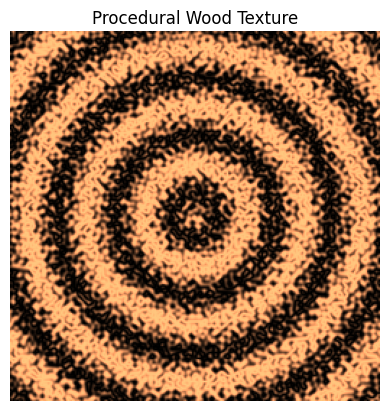

<Figure size 640x480 with 0 Axes>

In [ ]:
from src.noise import perlin_noise

noise = perlin_noise(SIZE, SIZE, scale=64, seed=1)

x = np.linspace(-1, 1, SIZE)
x, y = np.meshgrid(x, x)

radius = np.sqrt(x**2 + y**2)

wood = np.sin(20 * radius + noise * 5)
wood = (wood - wood.min()) / (wood.max() - wood.min())

plt.imshow(wood, cmap="copper")
plt.title("Procedural Wood Texture")
plt.axis("off")
plt.savefig(
    PROJECT_ROOT / "report" / "texture" / "wood.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

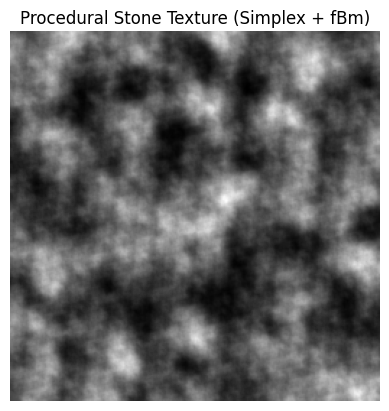

<Figure size 640x480 with 0 Axes>

In [ ]:
from src.noise import simplex_noise
from src.noise.fractal import fbm
import numpy as np
import matplotlib.pyplot as plt

SIZE = 256

stone = fbm(
    simplex_noise,
    SIZE,
    SIZE,
    scale=64,
    octaves=6,
    gain=0.5,
    lacunarity=2.0,
    seed=3,
)

# НОРМАЛИЗАЦИЯ В [0, 1]
stone = (stone - stone.min()) / (stone.max() - stone.min())

# Усиливаем контраст (имитация камня)
stone = np.power(stone, 1.5)

plt.imshow(stone, cmap="gray")
plt.title("Procedural Stone Texture (Simplex + fBm)")
plt.axis("off")
plt.savefig(
    PROJECT_ROOT / "report" / "texture" / "stone.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

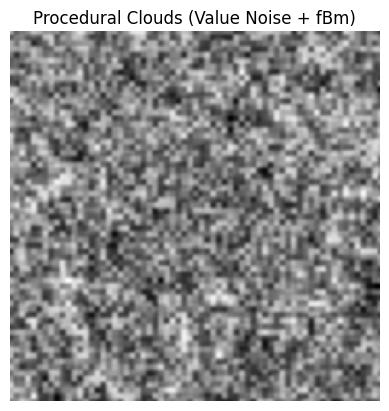

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.noise import value_noise
from src.noise.fractal import fbm

SIZE = 256

clouds = fbm(
    value_noise,
    SIZE,
    SIZE,
    scale=64,
    octaves=5,
    gain=0.6,
    lacunarity=2.0,
    seed=10,
)

clouds = (clouds - clouds.min()) / (clouds.max() - clouds.min())

plt.imshow(clouds, cmap="gray")
plt.title("Procedural Clouds (Value Noise + fBm)")
plt.axis("off")
plt.savefig(
    PROJECT_ROOT / "report" / "texture" / "clouds.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

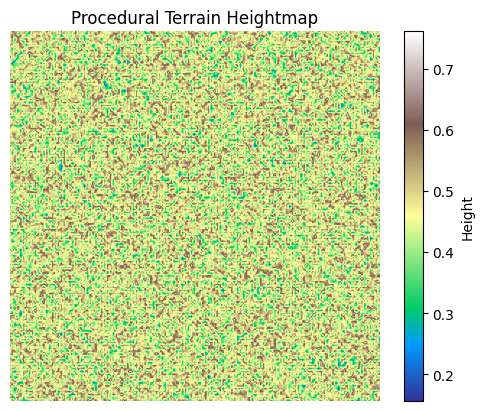

<Figure size 640x480 with 0 Axes>

In [ ]:
terrain = fbm(
    perlin_noise,
    SIZE,
    SIZE,
    scale=128,
    octaves=5,
    gain=0.5,
    lacunarity=2.0,
    seed=7,
)

plt.imshow(terrain, cmap="terrain")
plt.colorbar(label="Height")
plt.title("Procedural Terrain Heightmap")
plt.axis("off")
plt.savefig(
    PROJECT_ROOT / "report" / "texture" / "terrain.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()